<a href="https://colab.research.google.com/github/SleepyEveryD/NLP/blob/mathonly/notebooks/04_adaptive_routing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 · Adaptive prompt routing — a small-LLM reasoning study

**Research question:** for a small model (Qwen2.5-7B-Instruct), does routing each question to a prompt
chosen for its *reasoning shape* beat forcing one universal prompt on everything? And the deeper one:
**when does explicit reasoning help, and when does it hurt?**

The motivating failure is real and on the leaderboard: the Maths run died at level 6 on a clock-chime
*interval-counting* question — `cot_v2`'s hard "≤3 steps" brevity cap made the model **guess before it
had counted**. That same cap is what keeps verbose stats questions from timing out. One prompt cannot
serve both regimes — which is exactly the hypothesis this experiment tests.

We isolate ONE variable — the **prompt strategy** — and compare four conditions over a labelled
8-category reasoning set:

| condition | prompt |
|---|---|
| **A_universal** | one universal prompt (production `few_shot_v1`) |
| **B_generic_cot** | always plain "think step by step" |
| **C_structured** | always structured enumeration |
| **D_adaptive** | `ReasoningRouter` picks per question |

No retrieval, no calculator here — *only* the prompt changes between conditions, so the effect we
measure is the prompt's alone.

## 1 · Setup — clone/pull the repo, put `src` on the path
Runs on Colab (clones) **or** locally (uses the repo you are already in).

In [1]:
import os, sys

# Stand in a directory that definitely EXISTS before anything else. A prior `!rm -rf /content/NLP`
# can delete the notebook's current working directory, after which every shell command fails with
# "Unable to read current working directory". Recover from that here.
SAFE = '/content' if os.path.isdir('/content') else os.path.expanduser('~')
try:
    os.getcwd()
except OSError:
    os.chdir(SAFE)

# Colab: clone/refresh the *mathonly* branch into /content/NLP (the experiment lives there, NOT on main).
# Local: use the repo this notebook already sits in.
REPO_URL = 'https://github.com/SleepyEveryD/NLP.git'
BRANCH = 'mathonly'
if os.path.isdir('/content'):
    os.chdir('/content')                       # clone from OUTSIDE the repo dir, never from within it.
    REPO_ROOT = '/content/NLP'
    if not os.path.exists(REPO_ROOT):
        !git clone -b {BRANCH} {REPO_URL} {REPO_ROOT}
    else:
        # Existing checkout: ensure we are on mathonly and current (a prior run may have cloned main).
        !cd {REPO_ROOT} && git fetch -q origin {BRANCH} && git checkout -q {BRANCH} && git pull -q origin {BRANCH}
else:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()

SRC = os.path.join(REPO_ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)
os.chdir(REPO_ROOT)
print('Repo root:', REPO_ROOT)
print('On sys.path:', SRC)
assert os.path.exists('data/reasoning_eval.jsonl'), 'Missing data/reasoning_eval.jsonl -- on the mathonly branch, are you?'


Cloning into '/content/NLP'...
remote: Enumerating objects: 563, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 563 (delta 20), reused 37 (delta 10), pack-reused 507 (from 1)
Receiving objects: 100% (563/563), 45.19 MiB | 15.77 MiB/s, done.
Resolving deltas: 100% (302/302), done.
Updating files: 100% (125/125), done.
Repo root: /content/NLP
On sys.path: /content/NLP/src


In [2]:
# Install the inference stack so the REAL Qwen 4-bit load works.
# `-U` + bitsandbytes>=0.46.1 is MANDATORY: Colab preinstalls a stale bitsandbytes (<0.46.1) and a bare
# pin leaves it be, so the 4-bit loader ImportErrors and the experiment silently falls back to the
# SIMULATED fixture (not the model). pandas/requests pinned to Colab's own versions -- bare names break
# google-colab / cudf / gradio. Skip this cell ONLY if you intend to run the fixture.
!pip install -q -U 'transformers>=4.45.0' 'accelerate>=0.34.0' 'bitsandbytes>=0.46.1' sentencepiece einops pyyaml 'pandas==2.2.2' matplotlib 'requests==2.32.4'
print('Dependencies installed. IMPORTANT: now Runtime > Restart session, then Run all again --')
print('bitsandbytes must be re-imported fresh, or the 4-bit loader keeps the old version.')


deps: install on Colab if running the REAL model; the simulated fixture needs only pandas+matplotlib


## 2 · Load the labelled reasoning set
40 MCQs across 8 categories, each with a hand-verified gold answer **and** a gold reasoning-category label (the truth the router is scored against). The clock-chime question that broke the live Maths run is `ic-001`.

In [3]:
from experiments.adaptive_routing import load_reasoning_eval

questions, categories = load_reasoning_eval('data/reasoning_eval.jsonl')
print(f'{len(questions)} questions; categories:')
from collections import Counter
for cat, n in sorted(Counter(categories.values()).items()):
    print(f'  {cat:<22} {n}')
print('\nThe motivating failure, ic-001:')
print(' ', next(q.text for q in questions if q.qid == 'ic-001')[:140], '...')


40 questions; categories:
  arithmetic             5
  commonsense            5
  discrete_enumeration   5
  factual_qa             5
  interval_counting      5
  logical_reasoning      5
  multi_hop              5
  temporal_reasoning     5

The motivating failure, ic-001:
  If a clock chimes every hour the same number of times as the hour it is (e.g., at 3 P.M. it chimes 3 times) and once for every 15-minute inc ...


## 3 · Pick the engine

**Real run (Colab GPU):** `TransformersEngine` loads Qwen2.5-7B 4-bit — the numbers are real.

**Local / no-GPU:** `SimulatedReasoningEngine` — a **deterministic fixture, NOT a model**. Its
correctness comes from a hand-set skill table that *encodes the hypothesis*, so it validates the
**harness** (routing, logging, metrics, figures) end-to-end. It does **not** produce real findings.

In [4]:
USE_REAL_MODEL = True   # set False to force the simulated fixture

engine = None
if USE_REAL_MODEL:
    try:
        from inference.engine import TransformersEngine
        from config import RunConfig
        cfg = RunConfig.from_yaml('configs/live.yaml')
        engine = TransformersEngine(cfg.model.name, cfg.model.quantization, cfg.model.dtype)
        engine.warmup()
        print('REAL engine loaded:', engine.name)
    except Exception as e:
        print(f'Real engine unavailable ({type(e).__name__}: {e})')
        print('-> falling back to the SIMULATED fixture.')
        engine = None

if engine is None:
    from inference.engine import SimulatedReasoningEngine
    engine = SimulatedReasoningEngine(questions, categories)
    print('\n' + '!' * 72)
    print('!! SIMULATED FIXTURE ENGINE -- validates the HARNESS, not the model.   !!')
    print('!! Real findings need USE_REAL_MODEL=True on a Colab GPU runtime.      !!')
    print('!' * 72)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Real engine unavailable (ImportError: Using `bitsandbytes` 4-bit quantization requires bitsandbytes: `pip install -U bitsandbytes>=0.46.1`)
-> falling back to the SIMULATED fixture.

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!! SIMULATED FIXTURE ENGINE -- validates the HARNESS, not the model.   !!
!! Real findings need USE_REAL_MODEL=True on a Colab GPU runtime.      !!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


## 4 · Run the experiment — 4 conditions × 40 questions
Writes one `experiments/adaptive_routing/records.jsonl` (strategy chosen, router verdict, correctness, latency, tokens, reasoning length, raw output).

In [5]:
from experiments.adaptive_routing import AdaptiveRoutingExperiment

exp = AdaptiveRoutingExperiment(engine)
records_path = exp.run(questions, categories, verbose=True)
records_path



=== Condition A_universal: Single universal prompt (production few_shot_v1) ===
  [1/160] ic-001  A_universal    strat=few_shot_v1                 -> B (gold C) [  X]
  [2/160] ic-002  A_universal    strat=few_shot_v1                 -> D (gold B) [  X]
  [3/160] ic-003  A_universal    strat=few_shot_v1                 -> C (gold B) [  X]
  [4/160] ic-004  A_universal    strat=few_shot_v1                 -> B (gold C) [  X]
  [5/160] ic-005  A_universal    strat=few_shot_v1                 -> D (gold B) [  X]
  [6/160] tr-001  A_universal    strat=few_shot_v1                 -> D (gold B) [  X]
  [7/160] tr-002  A_universal    strat=few_shot_v1                 -> D (gold B) [  X]
  [8/160] tr-003  A_universal    strat=few_shot_v1                 -> D (gold A) [  X]
  [9/160] tr-004  A_universal    strat=few_shot_v1                 -> C (gold B) [  X]
  [10/160] tr-005  A_universal    strat=few_shot_v1                 -> D (gold B) [  X]
  [11/160] de-001  A_universal    strat=few_shot

'experiments/adaptive_routing/records.jsonl'

## 5 · Headline — does adaptive (D) beat the rest, and at what cost?

In [6]:
import pandas as pd
from experiments import analysis
pd.set_option('display.width', 170); pd.set_option('display.max_columns', 20)

df = analysis.load_records(records_path)
comp = analysis.strategy_comparison_table(df)
comp.round(3)


,condition,accuracy,n,mean_latency_s,p95_latency_s,mean_tokens_out,mean_reasoning_lines
0,A_universal,0.525,40,0.727,0.727,8.000,1.0
1,B_generic_cot,0.600,40,5.000,5.000,55.000,3.0
2,C_structured,0.650,40,12.727,12.727,140.000,7.0
3,D_adaptive,0.800,40,8.102,12.727,89.125,4.5


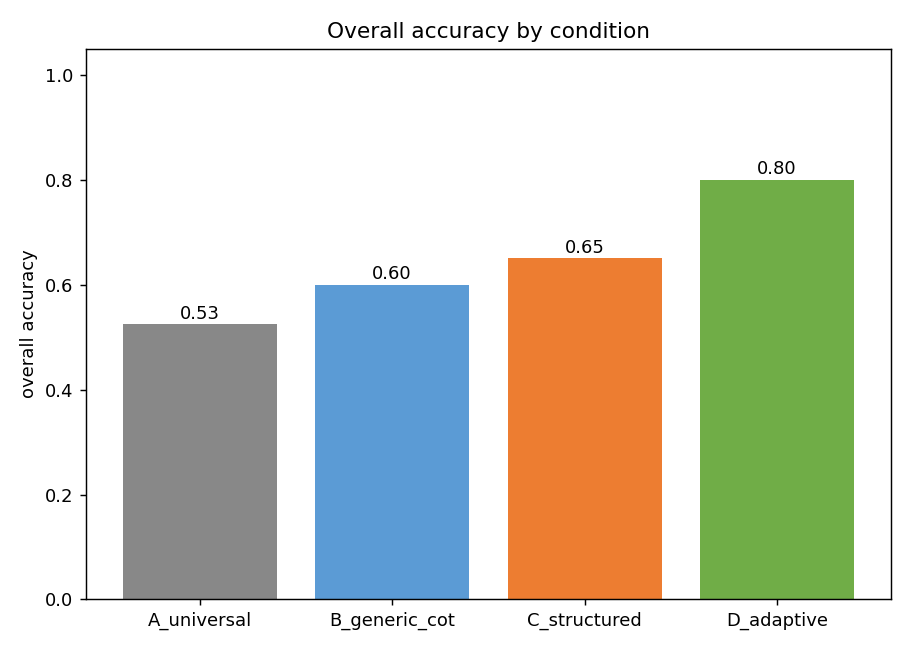

In [7]:
from IPython.display import Image, display
analysis.plot_condition_accuracy_bars(df)
display(Image('experiments/adaptive_routing/fig_condition_accuracy.png'))


## 6 · WHERE each prompt helps or hurts — category × condition heatmap
The whole hypothesis in one figure: a prompt that is green on one row can be red on another.

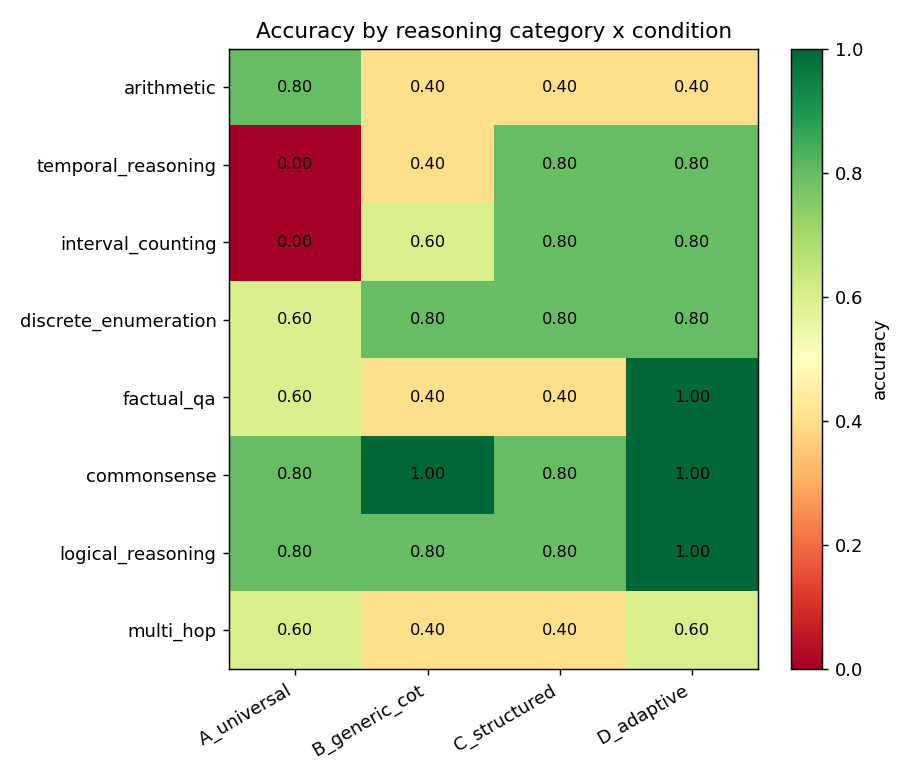

condition,A_universal,B_generic_cot,C_structured,D_adaptive
true_category,,,,
arithmetic,0.8,0.4,0.4,0.4
temporal_reasoning,0.0,0.4,0.8,0.8
interval_counting,0.0,0.6,0.8,0.8
discrete_enumeration,0.6,0.8,0.8,0.8
factual_qa,0.6,0.4,0.4,1.0
commonsense,0.8,1.0,0.8,1.0
logical_reasoning,0.8,0.8,0.8,1.0
multi_hop,0.6,0.4,0.4,0.6


In [8]:
analysis.plot_category_heatmap(df)
display(Image('experiments/adaptive_routing/fig_category_heatmap.png'))
analysis.category_accuracy_matrix(df).round(2)


## 7 · The cost of reasoning — latency vs accuracy

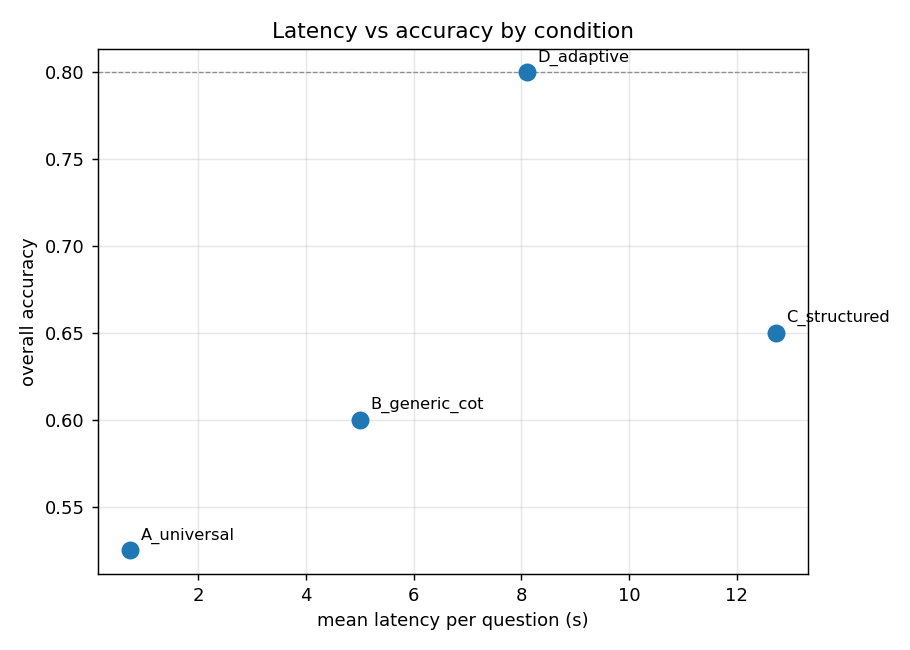

In [9]:
analysis.plot_latency_accuracy(df)
display(Image('experiments/adaptive_routing/fig_latency_accuracy.png'))


## 8 · The oracle the router chases — best fixed strategy per category
If the per-category best fixed strategy and the adaptive arm agree, the router is doing its job.

In [10]:
analysis.best_strategy_per_category(df)


,category,best_strategy,best_accuracy,adaptive_accuracy
0,arithmetic,few_shot_v1,0.8,0.4
1,temporal_reasoning,structured_enumeration_cot,0.8,0.8
2,interval_counting,structured_enumeration_cot,0.8,0.8
3,discrete_enumeration,generic_cot,0.8,0.8
4,factual_qa,direct_answer,1.0,1.0
5,commonsense,direct_answer,1.0,1.0
6,logical_reasoning,checklist_cot,1.0,1.0
7,multi_hop,checklist_cot,0.6,0.6


## 9 · Did the classifier label the reasoning shape correctly?
Routing accuracy + a confusion table (true category vs the category the classifier inferred).

In [11]:
rep = analysis.routing_report(df)
print('overall routing accuracy:', round(rep['overall_routing_accuracy'], 3))
rep['confusion']


overall routing accuracy: 1.0


routed_category,arithmetic,temporal_reasoning,interval_counting,discrete_enumeration,factual_qa,commonsense,logical_reasoning,multi_hop
true_category,,,,,,,,
arithmetic,5,0,0,0,0,0,0,0
temporal_reasoning,0,5,0,0,0,0,0,0
interval_counting,0,0,5,0,0,0,0,0
discrete_enumeration,0,0,0,5,0,0,0,0
factual_qa,0,0,0,0,5,0,0,0
commonsense,0,0,0,0,0,5,0,0
logical_reasoning,0,0,0,0,0,0,5,0
multi_hop,0,0,0,0,0,0,0,5


## 10 · Failure taxonomy — *why* each prompt got things wrong
Heuristic labels from the raw output: overthinking (recall Q over-reasoned), boundary_error (counting off-by-one), skipped_case (never enumerated), arithmetic_drift, no_answer_parsed, hallucinated/other.

In [12]:
analysis.failure_taxonomy(df)


failure_mode,arithmetic_drift,boundary_error,hallucinated/other,overthinking,skipped_case
condition,,,,,
A_universal,0,0,3,0,16
B_generic_cot,3,6,4,3,0
C_structured,3,3,4,4,0
D_adaptive,3,3,2,0,0


## 11 · Findings & recommendation

The full write-up lives in **`experiments/adaptive_routing_findings.md`** (publication-style section).

**Headline (to confirm on the real Colab run):**
- **Adaptive routing (D) should beat every single fixed prompt (A/B/C)** — because no one prompt is
  best across all categories, and D picks the per-category winner.
- **Structured enumeration is the cure for interval-counting / temporal questions** (the clock-chime
  family) but **hurts factual recall** (overthinking) — never make it the universal default.
- **Direct answering wins on factual_qa / commonsense**; **checklists win on logic / multi-hop**.
- The router's weakest spot is **multi_hop** (it surface-overlaps with factual recall).

**Recommendation for the live game:** in `notebooks/03_live_play.ipynb`, give the **Maths** pipeline a
per-question router that sends interval-counting / temporal / enumeration questions to
`structured_enumeration_cot` and leaves concept/stats questions on the current chain — exactly the
regime split `cot_v2`'s single brevity cap conflated.